In [1]:
!pip install "numpy<2.0.0"
# Then restart terminal

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install -qq medmnist
!pip install -qq av
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import sys
sys.path.append('/home/ubuntu/.lambda/lib/python3.10/site-packages')

In [4]:
import os
import cv2
import numpy as np
import tensorflow as tf  # for data preprocessing only
import keras
import av
import csv
import math
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

2024-12-31 20:51:34.446299: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-31 20:51:34.459816: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1735678294.476183  148442 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1735678294.481627  148442 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-31 20:51:34.497221: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [5]:
DATA_DIR = 'dataset2/videos'
LABEL_DIRS = ['dataset2/annotations1', 'dataset2/annotations2', 'dataset2/annotations3', 
              'dataset2/annotations4', 'dataset2/annotations5']
NUM_CLASSES = 8 # Added one in case of washing but not doing any step
MAX_VIDEOS = 400 # Limiting the number of videos to combat memory issues temporarily

TEST_SIZE = 0.2
VAL_SIZE = 0.2
DATASET_SEED = 81

FRAME_SIZE = (360, 240)
SCALE = 255.0
CLIP_LENGTH = 400 # 120 runs into errors

INPUT_SHAPE = (210, 270, 1) # coordinates are inverted for some reason
NUM_FRAMES = 3

# TRAINING
BATCH_SIZE = 32 # down from 64 because of frame size
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 100

In [6]:
def prepare_dataset(data_dir, test_size=TEST_SIZE, val_size=VAL_SIZE, random_state=DATASET_SEED, limit=MAX_VIDEOS):
    video_lengths = []
    videos = os.listdir(data_dir)
    
    i = 0
    for video_file in videos:
        if i >= limit:
            break
        i += 1
        
        if os.path.isdir(video_file):
                continue
        video_path = os.path.join(data_dir, video_file)
        video_reader = cv2.VideoCapture(video_path)
        frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
        height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))
        width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))

        video_name, _ = os.path.splitext(video_file)
        video_lengths.append((video_path, video_name, frames_count, (height, width)))
        video_reader.release()
    print(i)
    
    return video_lengths

In [7]:
def prepare_annotations(current_directory):
    all_annotations = {}

    annotations = os.listdir(current_directory)
    for file in annotations:
        file_name, file_extension = os.path.splitext(file)
        if file_extension.lower() == '.csv':
            file_path = os.path.join(current_directory, file)

            file_data = {}
            with open(file_path, mode='r') as reading_file:
                csv_reader = csv.reader(reading_file)
                for i, row in enumerate(csv_reader):
                    if i != 0:
                        frame = float(row[0])
                        fixfr = math.floor(frame)
                        frame_num = 3 * (fixfr // 100) + ((fixfr % 100) // 33)
                        file_data[frame_num] = (int(row[1]), int(row[2]))
                        
            # There is only one annotation per file, if this is not true this doesn't work
            all_annotations[file_name] = file_data

    return all_annotations

In [8]:
# Deletes any erroneous references in the set of all annotations (videos do not exist)
def purge_annotations(videos, ants):
    all_collected = set()
    for video in videos:
        all_collected.add(video[1])

    i = 0
    error_annotations = []
    
    for annotation in ants:
        for name in annotation.keys():
            if name not in all_collected:
                error_annotations.append((annotation, name))
                i += 1
    for annotation, name in error_annotations:
        i -= 1
        del annotation[name] # Uncomment if you want actual functionality

# Deletes any videos which do not have any annotations
def purge_videos(videos, ants):
    i = 0
    for info in videos:
        flag = False
        for ann in ants:
            if info[1] in ann:
                flag = True
        if not flag:
            os.remove(info[0]) # Uncomment if you want actual functionality
            i += 1

In [9]:
def combine_annotations(videos, ants):
    all_names = {}
    for info in videos:
        all_names[info[1]] = [[] for _ in range(info[2])] # create a list for each frame of the video
            
    for ann in ants:
        for name in ann.keys():
            for frame_num in ann[name].keys():
                if frame_num < len(all_names[name]):
                    all_names[name][frame_num].append(ann[name][frame_num])
    return all_names

In [10]:
video_info = prepare_dataset(DATA_DIR)

annotations = []
for annotation_dir in LABEL_DIRS:
    annotations.append(prepare_annotations(annotation_dir))

purge_annotations(video_info, annotations)
purge_videos(video_info, annotations)
combined_annotations = combine_annotations(video_info, annotations)

387


In [11]:
len(video_info)
len(os.listdir(DATA_DIR))

387

In [12]:
# This block of code computes all the frame sizes and how many annotations per video
frame_sizes = {}
annotations_per_video = []

for info in video_info:
    annotations_per_video.append(0)
    if info[1] in annotations:
        annotations_per_video[-1] += 1
    if info[3] not in frame_sizes:
        frame_sizes[info[3]] = [info]
    else:
        frame_sizes[info[3]].append(info)

In [13]:
def read_video_pyav(container, indices, comb_video_ann, name, new_size=FRAME_SIZE, scale=SCALE):
    '''Decode the video with PyAV decoder, filtering for only frames with hand-washing.
    Args:
        container (`av.container.input.InputContainer`): PyAV container.
        indices (`List[int]`): List of frame indices to decode.
    Returns:
        result (np.ndarray): np array of decoded frames of shape (num_frames, height, width, 3).'''
    frames = []
    names = []
    frame_numbers = []
    start_index = indices[0]
    end_index = indices[-1]
    
    container.seek(0)
    for i, frame in enumerate(container.decode(video=0)):
        if i > end_index:
            break
        # Ignore frame if no annotator looked at it
        if i >= start_index and len(comb_video_ann[i]) > 0:
            # If any annotator thinks there is no washing, do not include in data
            not_washing = any(datum[0] == 0 for datum in comb_video_ann[i]) or comb_video_ann[i][-1][1] == 0
            
            if not not_washing:
                
                new_frame = frame.to_ndarray(format="rgb24")
                new_frame = cv2.cvtColor(new_frame, cv2.COLOR_RGB2GRAY)
                new_frame = new_frame / scale
                new_frame = cv2.resize(new_frame, new_size)
                frames.append(new_frame)
                names.append(name)
                frame_numbers.append(i)
                
    return frames, names, frame_numbers

In [14]:
def sample_frame_indices(frame_sample_rate, seg_len, clip_len=CLIP_LENGTH):
    '''Sample a given number of frame indices from the video.
    Args:
        clip_len (`int`): Total number of frames to sample.
        frame_sample_rate (`int`): Sample every n-th frame.
        seg_len (`int`): Maximum allowed index of sample's last frame.
    Returns:
        indices (`List[int]`): List of sampled frame indices'''
    converted_len = int(clip_len * frame_sample_rate)
    # end_idx = np.random.randint(converted_len, seg_len)
    end_idx = seg_len # Always picking the last CLIP_LENGTH many frames
    start_idx = end_idx - converted_len
    indices = np.linspace(start_idx, end_idx, num=clip_len)
    indices = np.clip(indices, start_idx, end_idx - 1).astype(np.int64)
    return indices

In [15]:
def download_and_prepare_dataset(video_directories: list, all_annotations: dict):
    """Utility function to download dataset
    Arguments:
        list of addresses of videos
    Returns:
        list of videos, each of different dimension"""
    
    frames = []
    names = []
    frame_numbers = []
    
    i = 0
    for info in video_directories:
        i += 1
        print(f"\r{int(10000 * i / (len(video_directories))) / 100}%   ", end="")
        address = info[0]
        vid_container = av.open(address)
        
        vid_indices = sample_frame_indices(frame_sample_rate=1, seg_len=info[2])
        v_frames, v_names, v_fr_nums = read_video_pyav(container=vid_container, indices=vid_indices, name=info[1],
                                                       comb_video_ann=all_annotations[info[1]])
        frames.extend(v_frames)
        names.extend(v_names)
        frame_numbers.extend(v_fr_nums)
        
    print("Completed download of videos")

    print("Copying frames")
    resized_list = np.stack(frames)
    
    print("Adding labels")
    resized_labels = np.zeros((len(frames)), dtype=np.float32)

    # I picked the last annotator every time (last annotators are responsible for more videos and could be
    # more accurate), this is arbitrary, there are at most 3 annotators and I beleive this is reasonable
    for j in range(len(frames)):
        name = names[j]
        frame_num = frame_numbers[j]
        resized_labels[j] = all_annotations[name][frame_num][-1][1]

    print(f"Videos shape: {np.array(resized_list).shape}")
    print(f"Labels shape: {np.array(resized_labels).shape}")
    print()
    return (resized_list, resized_labels)


In [16]:

train_info, test_val_info = train_test_split(video_info, test_size=TEST_SIZE+VAL_SIZE, random_state=DATASET_SEED)
val_info, test_info = train_test_split(test_val_info, test_size=TEST_SIZE/(TEST_SIZE+VAL_SIZE), random_state=DATASET_SEED)

print("Downloading train data")
train_frames, train_labels = download_and_prepare_dataset(train_info, combined_annotations)
print("Downloading validation data")
val_frames, val_labels = download_and_prepare_dataset(val_info, combined_annotations)
print("Downloading test data")
test_frames, test_labels = download_and_prepare_dataset(test_info, combined_annotations)


100.0%   Completed download of videos
Copying frames
Adding labels
Videos shape: (12187, 240, 360)
Labels shape: (12187,)

100.0%   Completed download of videos
Copying frames
Adding labels
Videos shape: (2687, 240, 360)
Labels shape: (2687,)

Completed download of videos
Copying frames
Adding labels
Videos shape: (3326, 240, 360)
Labels shape: (3326,)



The above code splits the videos into test train and validation, and then trains on these videos.
Below, it splits the frames by test train and validation. It is likely that adjacent frames are similar, and if enough parameters exist you will see overfitting, which I find very likely.

In [17]:
"""
print("Downloading all data")
all_frames, all_labels = download_and_prepare_dataset(video_info, combined_annotations)

# Splitting the data (it is likely there is overfitting due to this decision)
train_frames, test_val_frames = train_test_split(all_frames, test_size=TEST_SIZE+VAL_SIZE, random_state=DATASET_SEED)
train_labels, test_val_labels = train_test_split(all_labels, test_size=TEST_SIZE+VAL_SIZE, random_state=DATASET_SEED)

val_frames, test_frames = train_test_split(test_val_frames, test_size=TEST_SIZE/(TEST_SIZE+VAL_SIZE), random_state=DATASET_SEED)
val_labels, test_labels = train_test_split(test_val_labels, test_size=TEST_SIZE/(TEST_SIZE+VAL_SIZE), random_state=DATASET_SEED)
"""

'\nprint("Downloading all data")\nall_frames, all_labels = download_and_prepare_dataset(video_info, combined_annotations)\n\n# Splitting the data (it is likely there is overfitting due to this decision)\ntrain_frames, test_val_frames = train_test_split(all_frames, test_size=TEST_SIZE+VAL_SIZE, random_state=DATASET_SEED)\ntrain_labels, test_val_labels = train_test_split(all_labels, test_size=TEST_SIZE+VAL_SIZE, random_state=DATASET_SEED)\n\nval_frames, test_frames = train_test_split(test_val_frames, test_size=TEST_SIZE/(TEST_SIZE+VAL_SIZE), random_state=DATASET_SEED)\nval_labels, test_labels = train_test_split(test_val_labels, test_size=TEST_SIZE/(TEST_SIZE+VAL_SIZE), random_state=DATASET_SEED)\n'

In [18]:
def preprocess(frame: tf.Tensor, label: tf.Tensor):
    """Preprocess the frames tensors and parse the labels."""
    frame = frame[..., tf.newaxis]
    frame = tf.image.random_crop(frame, size=(INPUT_SHAPE[0], INPUT_SHAPE[1], INPUT_SHAPE[2]))
    frame = tf.image.random_flip_up_down(frame)
    frame = tf.image.random_brightness(frame, 0.2)
    return frame, label

def prepare_dataloader(
    videos: np.ndarray,
    labels: np.ndarray,
    loader_type: str = "train",
    batch_size: int = BATCH_SIZE,
):
    """Utility function to prepare the dataloader."""
    dataset = tf.data.Dataset.from_tensor_slices((videos, labels))

    if loader_type == "train":
        dataset = dataset.shuffle(BATCH_SIZE * 2)

    dataloader = (
        dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )
    return dataloader

In [19]:
trainloader = prepare_dataloader(train_frames, train_labels, "train")
validloader = prepare_dataloader(val_frames, val_labels, "valid")
testloader = prepare_dataloader(test_frames, test_labels, "test")

I0000 00:00:1735678394.192414  148442 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20732 MB memory:  -> device: 0, name: NVIDIA A10, pci bus id: 0000:07:00.0, compute capability: 8.6


In [20]:
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical

In [21]:
model = Sequential([
    Conv2D(48, (7, 7), activation='relu', input_shape=INPUT_SHAPE), # Layer 1
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    Conv2D(128, (5, 5), activation='relu'), # Layer 2
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(196, (3, 3), activation='relu'), # Layer 3
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(256, (3, 3), activation='relu'), # Layer 4
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(384, (3, 3), activation='relu'), # Layer 5
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    Conv2D(896, (3, 3), activation='relu'), # Layer 6 (increased output dimension 512 -> 896)
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    
    Dense(1024, activation='relu'), # Layer 7 (new layer after flatten)
    BatchNormalization(),
    
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    
    Dense(NUM_CLASSES, activation='softmax')
])

optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
    ],
)

history = model.fit(trainloader, epochs=EPOCHS, validation_data=validloader)

_, accuracy, top_5_accuracy = model.evaluate(testloader)
print(f"Test accuracy: {round(accuracy * 100, 2)}%")
print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

/usr/lib/python3/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100


I0000 00:00:1735678411.618859  154816 service.cc:148] XLA service 0x73bc84002800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1735678411.618911  154816 service.cc:156]   StreamExecutor device (0): NVIDIA A10, Compute Capability 8.6
2024-12-31 20:53:31.710753: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1735678412.105168  154816 cuda_dnn.cc:529] Loaded cuDNN version 90501


  1/381 ━━━━━━━━━━━━━━━━━━━━ 1:42:31 16s/step - accuracy: 0.1562 - loss: 3.2295 - top-5-accuracy: 0.5234

I0000 00:00:1735678421.081589  154816 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


381/381 ━━━━━━━━━━━━━━━━━━━━ 49s 86ms/step - accuracy: 0.2186 - loss: 2.8853 - top-5-accuracy: 0.6887 - val_accuracy: 0.0421 - val_loss: 5.7631 - val_top-5-accuracy: 0.4176
Epoch 2/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.2739 - loss: 2.3934 - top-5-accuracy: 0.7338 - val_accuracy: 0.2698 - val_loss: 2.4675 - val_top-5-accuracy: 0.6260
Epoch 3/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.3203 - loss: 2.1549 - top-5-accuracy: 0.7609 - val_accuracy: 0.3785 - val_loss: 2.1941 - val_top-5-accuracy: 0.6848
Epoch 4/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.3711 - loss: 1.9647 - top-5-accuracy: 0.7990 - val_accuracy: 0.3822 - val_loss: 2.6276 - val_top-5-accuracy: 0.6453
Epoch 5/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.4189 - loss: 1.8248 - top-5-accuracy: 0.8281 - val_accuracy: 0.4581 - val_loss: 1.9420 - val_top-5-accuracy: 0.7968
Epoch 6/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.4410 - loss: 1.755

104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step   


2024-12-31 21:27:59.623686: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/tmp/ipykernel_148442/4164891165.py:18: RuntimeWarning: invalid value encountered in divide
  cm_percentage = np.nan_to_num(cm.astype('float') / cm.sum(axis=1, keepdims=True), nan=0.0)


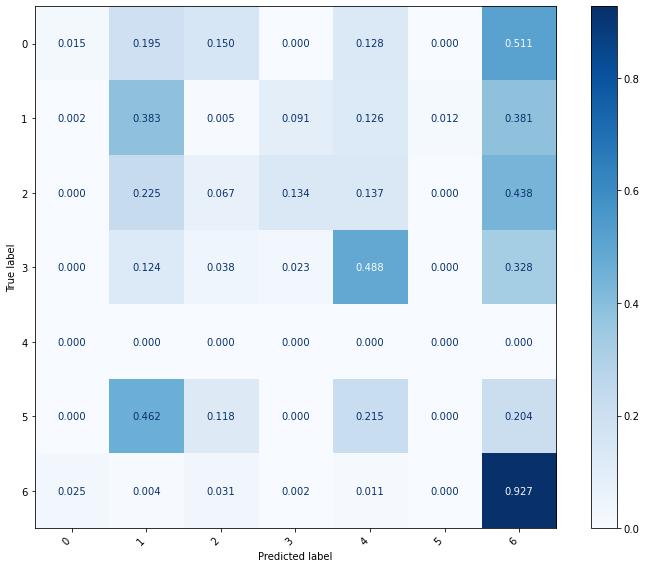

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Get predictions from the trained model
y_pred_probs = model.predict(testloader)  # Predict probabilities for each class

# Step 2: Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 3: Get true labels
y_true = np.concatenate([y.numpy() for x, y in testloader], axis=0)

# Step 4: Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize each row (true class) to percentages
cm_percentage = np.nan_to_num(cm.astype('float') / cm.sum(axis=1, keepdims=True), nan=0.0)

# Dynamically determine the number of classes
n_classes = cm.shape[0]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=range(n_classes))

# Step 5: Display the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.3f')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()